# We will be working on Titanic Dataset: we will try to predict if a passenger is going to survive or not.

In [1]:
import pandas as pd 
dataset=pd.read_csv("titanic-passengers.csv", sep=";")
#Preprocessing our data
def preprocess_data(new_data):
    new_data.fillna({'Age': new_data['Age'].mean()},inplace=True)
    new_data['Sex']=new_data['Sex'].map({'male': 1,'female':0})
    new_data['Cabin']=new_data.Cabin.fillna('G6')
    new_data['Survived']=new_data['Survived'].map({'Yes': 1,'No':0})
    return new_data
data=preprocess_data(dataset)

In [2]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,343,0,2,"Collander, Mr. Erik Gustaf",1,28.0,0,0,248740,13.0000,G6,S
1,76,0,3,"Moen, Mr. Sigurd Hansen",1,25.0,0,0,348123,7.6500,F G73,S
2,641,0,3,"Jensen, Mr. Hans Peder",1,20.0,0,0,350050,7.8542,G6,S
3,568,0,3,"Palsson, Mrs. Nils (Alma Cornelia Berglund)",0,29.0,0,4,349909,21.0750,G6,S
4,672,0,1,"Davidson, Mr. Thornton",1,31.0,1,0,F.C. 12750,52.0000,B71,S


# Decision Tree Prediction

In [3]:
#importing relevant libraries
from sklearn.model_selection import train_test_split   
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
#features extraction
x=data.drop(["Survived", "Name", "Cabin", "Ticket", "Embarked"], axis=1)
y= data["Survived"]
#splitting data
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.20,random_state=10)
#applying tree algorithm
clf = DecisionTreeClassifier()  
clf.fit(x_train, y_train)   #fitting our model
y_pred=clf.predict(x_test)   # evaluating our model
print("score:{}".format(accuracy_score(y_test, y_pred)))

score:0.776536312849162


# Decision Tree Visualization

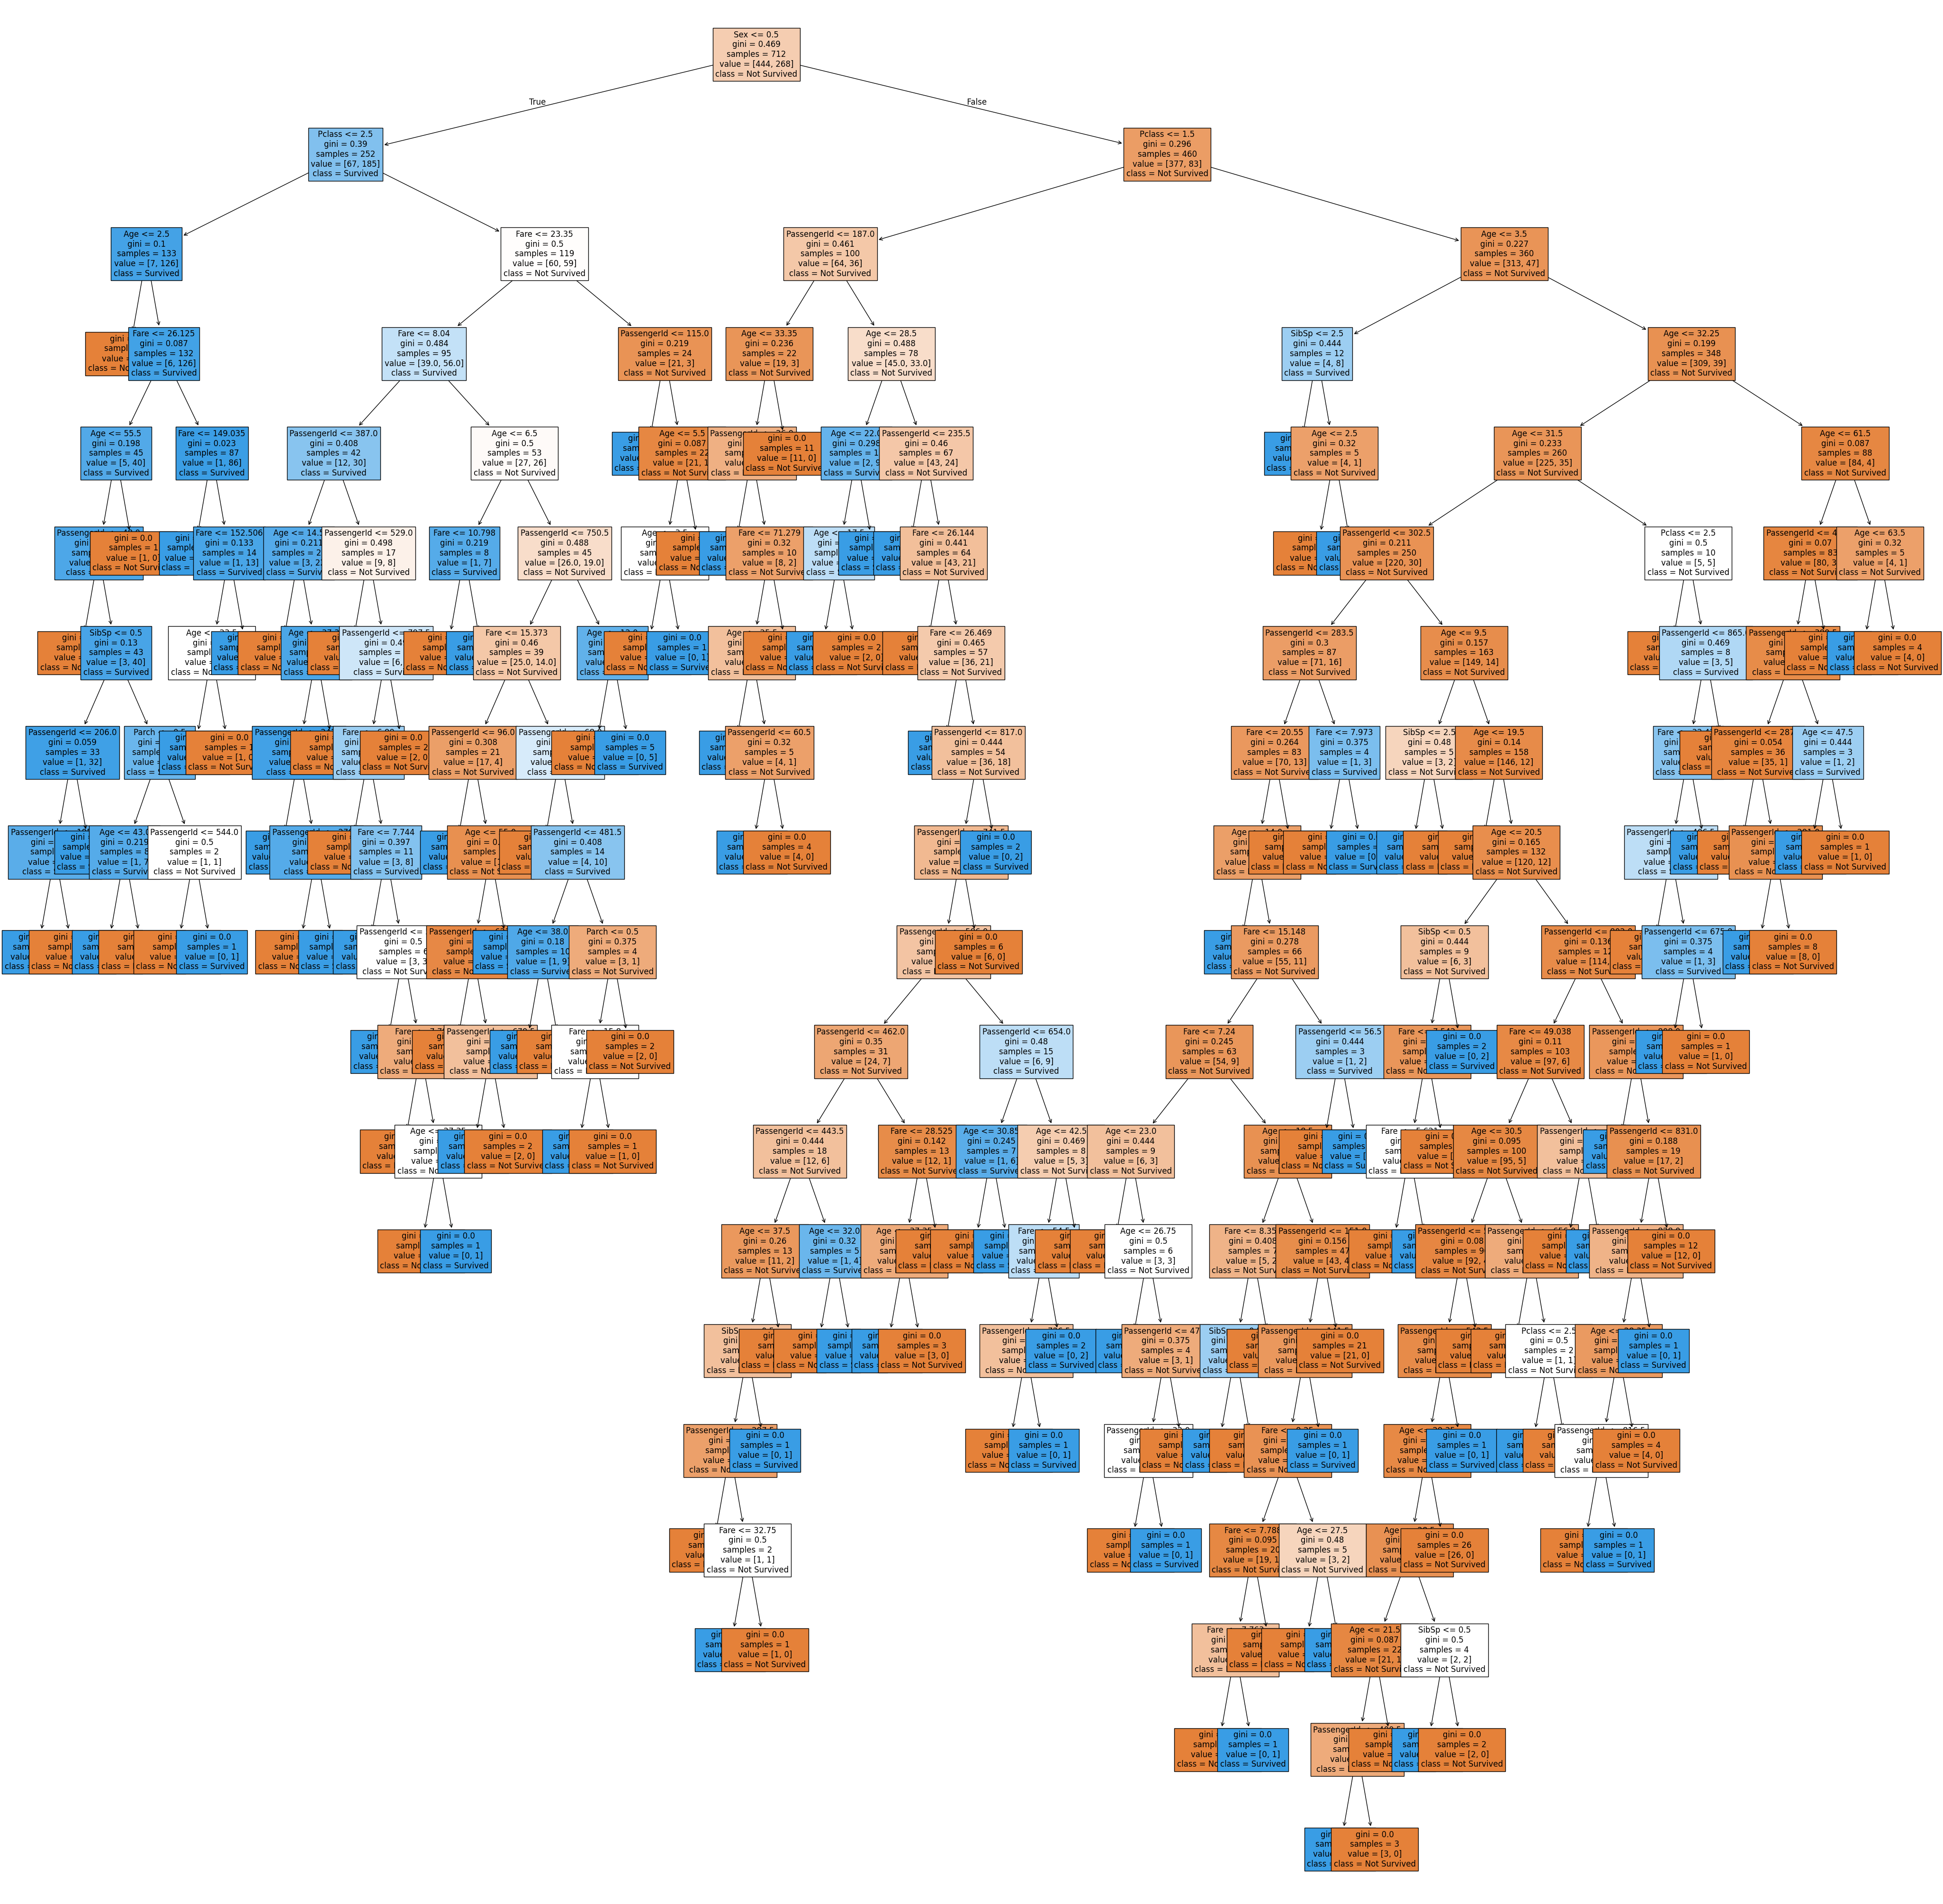

In [4]:
import matplotlib.pyplot as plt
from sklearn import tree

# Set figure size
plt.figure(figsize=(50,50))

# Plot the decision tree with increased font size
tree.plot_tree(clf, feature_names=x.columns, class_names=["Not Survived", "Survived"], filled=True, fontsize=12)

# Adjust the plot to fit
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)

# Show the plot
plt.show()


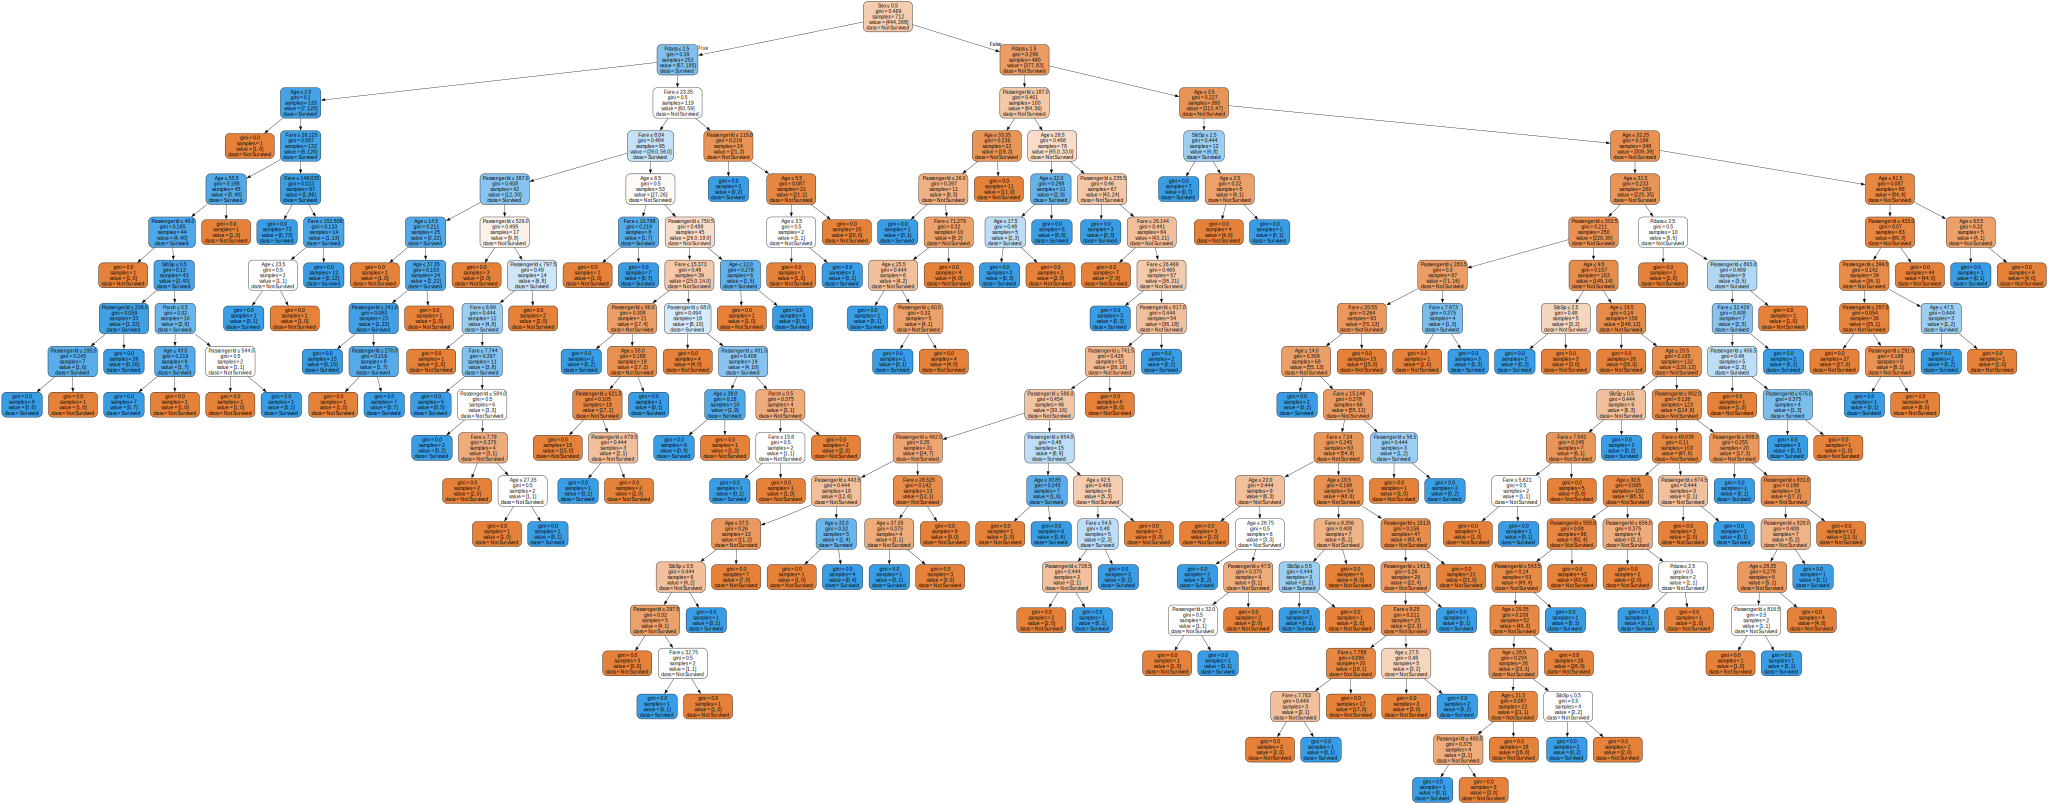

In [5]:
import graphviz
from sklearn.tree import export_graphviz

# Visualizing the Decision Tree with Graphviz
dot_data = export_graphviz(
    clf, out_file=None,
    feature_names=x.columns,
    class_names=["Not Survived", "Survived"],
    filled=True, rounded=True, special_characters=True
)

# Render the tree
graph = graphviz.Source(dot_data)
graph  # Displays the tree in Jupyter Notebook